# 04b — SARIMA (Weekly Version)
## Per-Item Weekly Forecasting with Seasonal ARIMA

**Why SARIMA at weekly?** SARIMA captures autoregressive and seasonal structure
without explicit feature engineering. At weekly level the seasonal period
shifts from m=7 (daily, weekly cycle) to a different value.

**Critical decision: which seasonal period?** Yearly seasonality (m=52) needs
~2 full cycles of training data, but we only have ~58 weeks of training.
That's barely 1.1 cycles — not enough for stable yearly SARIMA. Two strategies:

- **Strategy 1:** m=52 with `D=0` (no seasonal differencing) — let auto_arima
  decide if seasonal component fits or not
- **Strategy 2:** m=4 (monthly cycle within the data) — more reliable but
  may miss yearly patterns

We try Strategy 1 first; if auto_arima fails or returns nonseasonal models for
most items, we fall back to Strategy 2.

**Input:** `weekly_item_demand.csv`

**Outputs:**
- `sarima_predictions_weekly.csv`
- `sarima_metrics_weekly.csv`
- `sarima_summary_weekly.json`
- `models/sarima/<item>.pkl` × 122

---

## 1. Setup

In [1]:
import os
import json
import time
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pmdarima import auto_arima
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATASETS_DIR = '../../datasets'
MODELS_DIR = '../../models/sarima'
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 10

print(f"Working directory: {os.getcwd()}")
print(f"Models will be saved to: {os.path.abspath(MODELS_DIR)}")

Working directory: c:\Users\slimc\Desktop\Notebooks\Module 2\Sarima
Models will be saved to: c:\Users\slimc\Desktop\Notebooks\models\sarima


## 2. Load weekly data

In [2]:
df = pd.read_csv(os.path.join(DATASETS_DIR, 'weekly_item_demand.csv'),
                  parse_dates=['week_start'])
df = df.sort_values(['item_name', 'week_start']).reset_index(drop=True)

print(f"Loaded: {len(df):,} rows")
print(f"Date range: {df['week_start'].min().date()} → {df['week_start'].max().date()}")
print(f"Weeks: {df['week_start'].nunique()}")
print(f"Items: {df['item_name'].nunique()}")

# Training weeks per item
train_weeks = df[df['split']=='train'].groupby('item_name').size()
print(f"\nTrain weeks per item: {train_weeks.iloc[0]} (same for all items)")
print(f"Val weeks: {df[df['split']=='val'].groupby('item_name').size().iloc[0]}")
print(f"Test weeks: {df[df['split']=='test'].groupby('item_name').size().iloc[0]}")

Loaded: 19,032 rows
Date range: 2023-01-03 → 2025-12-23
Weeks: 156
Items: 122

Train weeks per item: 104 (same for all items)
Val weeks: 13
Test weeks: 39


## 3. Metric functions (same as everywhere)

In [3]:
def compute_metrics(actual, predicted, train_actual=None):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = actual - predicted
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt((errors**2).mean())
    bias = errors.mean()

    nonzero = actual > 0
    mape = (abs_errors[nonzero] / actual[nonzero]).mean() if nonzero.sum() > 0 else np.nan

    denom = (np.abs(actual) + np.abs(predicted)) / 2
    smape_mask = denom > 0
    smape = (abs_errors[smape_mask] / denom[smape_mask]).mean() if smape_mask.sum() > 0 else np.nan

    actual_sum = actual.sum()
    wape = abs_errors.sum() / actual_sum if actual_sum > 0 else np.inf

    ss_res = (errors**2).sum()
    ss_tot = ((actual - actual.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    mase = np.nan
    if train_actual is not None and len(train_actual) > 1:
        naive_errors = np.abs(train_actual[1:] - train_actual[:-1])
        mae_naive = naive_errors.mean()
        if mae_naive > 0:
            mase = mae / mae_naive

    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'smape': smape,
            'wape': wape, 'mase': mase, 'r2': r2, 'bias': bias}

print("Metric function ready")

Metric function ready


## 4. Train SARIMA per item with auto_arima

For each item:
1. Fit `auto_arima` with seasonal=True, **m=52** (yearly cycle on weekly data)
2. Predict val + test horizon (~52 weeks total)
3. Save fitted model

**Why m=52?** With 96 training weeks (~1.85 yearly cycles) and 3 Ramadan periods
across train+val+test, yearly seasonality is now legitimately fittable. This
matches Prophet's `yearly_seasonality=True` configuration and lets SARIMA
compete on equal footing rather than being forced to ignore the dominant
long-range signal.

**Trade-off:** 1.85 cycles is on the thin side for stable yearly seasonal
differencing. Some low-volume items will fail auto_arima fitting — for those,
the fallback is seasonal-naive at lag-52 ("same week last year"), which is
the principled baseline at this granularity.

Expect 10-20 minutes total runtime due to the larger seasonal search space.


In [4]:
items = sorted(df['item_name'].unique())
print(f"Training SARIMA on {len(items)} items...")

predictions_list = []
fitted_models = {}
failed_items = []

start_time = time.time()

for i, item in enumerate(items):
    item_df = df[df['item_name'] == item].sort_values('week_start')

    train = item_df[item_df['split'] == 'train']
    val = item_df[item_df['split'] == 'val']
    test = item_df[item_df['split'] == 'test']

    train_qty = train['quantity'].values
    n_forecast = len(val) + len(test)

    try:
        # auto_arima at m=52 (yearly seasonality on weekly data)
        # Conservative AR/MA bounds; seasonal terms kept small to avoid
        # overfitting on only 1.85 yearly cycles of training data.
        model = auto_arima(
            train_qty,
            seasonal=True,
            m=52,                      # yearly cycle on weekly data
            max_p=3, max_q=3,          # keep search space small
            max_P=1, max_Q=1,          # tight seasonal bounds (1.85 cycles available)
            d=None, D=None,            # let auto detect differencing
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=False,
            information_criterion='aic',
            n_jobs=1,
        )

        forecast = model.predict(n_periods=n_forecast)
        forecast = np.clip(np.asarray(forecast), 0, None)

        forecast_dates = list(val['week_start'].values) + list(test['week_start'].values)
        for j, fdate in enumerate(forecast_dates):
            row = item_df[item_df['week_start'] == fdate].iloc[0]
            predictions_list.append({
                'ds': fdate,
                'item_name': item,
                'section': row['section'],
                'category': row['category'],
                'actual': row['quantity'],
                'predicted': float(forecast[j]),
                'split': row['split'],
            })

        fitted_models[item] = model

        if (i + 1) % 20 == 0 or (i + 1) == len(items):
            elapsed = time.time() - start_time
            print(f"  [{i+1}/{len(items)}]  {item:<40s} order={model.order} seasonal={model.seasonal_order}  ({elapsed:.0f}s)")

    except Exception as e:
        # Fallback: seasonal-naive at lag-52 (same week last year).
        # Principled choice for weekly data with annual cyclicality.
        if len(train_qty) >= 52:
            # Repeat the last 52 training weeks, tiled across the forecast horizon
            base = train_qty[-52:]
        else:
            # Very short series — fall back to mean of available history
            base = np.array([train_qty.mean()] * 52)
        forecast = np.tile(base, n_forecast // 52 + 1)[:n_forecast]
        forecast = np.clip(forecast, 0, None)

        forecast_dates = list(val['week_start'].values) + list(test['week_start'].values)
        for j, fdate in enumerate(forecast_dates):
            row = item_df[item_df['week_start'] == fdate].iloc[0]
            predictions_list.append({
                'ds': fdate,
                'item_name': item,
                'section': row['section'],
                'category': row['category'],
                'actual': row['quantity'],
                'predicted': float(forecast[j]),
                'split': row['split'],
            })

        failed_items.append((item, str(e)[:80]))
        print(f"  [{i+1}/{len(items)}]  {item:<40s} FAILED → fallback to seasonal-naive (lag-52)")

predictions_df = pd.DataFrame(predictions_list)
total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"✓ Training complete: {total_time:.0f}s")
print(f"✓ Items succeeded:   {len(items) - len(failed_items)} / {len(items)}")
print(f"✓ Predictions:       {len(predictions_df):,} rows")
if failed_items:
    print(f"\n✗ Failed items (using fallback):")
    for item, err in failed_items[:5]:
        print(f"    {item}: {err}")
    if len(failed_items) > 5:
        print(f"    ... and {len(failed_items)-5} more")


Training SARIMA on 122 items...
  [20/122]  Caramel Flan                             order=(0, 0, 0) seasonal=(0, 0, 0, 52)  (162s)
  [40/122]  Crème Brûlée                             order=(0, 0, 0) seasonal=(0, 0, 1, 52)  (348s)
  [60/122]  Horchata                                 order=(0, 0, 0) seasonal=(0, 0, 0, 52)  (523s)
  [80/122]  Oatmeal with Berries                     order=(2, 0, 0) seasonal=(1, 0, 0, 52)  (675s)
  [90/122]  Pork Ramen                               FAILED → fallback to seasonal-naive (lag-52)
  [100/122]  Roasted Chickpeas                        order=(0, 0, 0) seasonal=(0, 0, 0, 52)  (874s)
  [120/122]  Vegan Peanut Butter Protein Ball         order=(0, 1, 2) seasonal=(0, 0, 0, 52)  (1018s)
  [122/122]  White Wine (Pinot Grigio)                order=(1, 0, 1) seasonal=(0, 0, 0, 52)  (1029s)

✓ Training complete: 1029s
✓ Items succeeded:   121 / 122
✓ Predictions:       6,344 rows

✗ Failed items (using fallback):
    Pork Ramen: There are no more sample

## 5. Naive baselines

In [5]:
naive_results = {'seasonal_naive': [], 'mean': [], 'last_value': []}

train_data_dict = {}
for item in items:
    train_qty = df[(df['item_name'] == item) & (df['split'] == 'train')].sort_values('week_start')['quantity'].values
    train_data_dict[item] = train_qty

for item in items:
    item_train = df[(df['item_name'] == item) & (df['split'] == 'train')].sort_values('week_start')
    item_actual = df[(df['item_name'] == item) & (df['split'].isin(['val', 'test']))].sort_values('week_start')

    train_qty = item_train['quantity'].values
    actual_qty = item_actual['quantity'].values
    n_forecast = len(actual_qty)

    last_4w = train_qty[-4:] if len(train_qty) >= 4 else train_qty
    seasonal_pred = np.tile(last_4w, n_forecast // 4 + 1)[:n_forecast]
    mean_pred = np.full(n_forecast, train_qty.mean())
    last_pred = np.full(n_forecast, train_qty[-1])

    for name, pred in [('seasonal_naive', seasonal_pred), ('mean', mean_pred), ('last_value', last_pred)]:
        for split in ['val', 'test']:
            split_mask = item_actual['split'].values == split
            if split_mask.sum() > 0:
                m = compute_metrics(actual_qty[split_mask], pred[split_mask], train_qty)
                m['item_name'] = item
                m['split'] = split
                naive_results[name].append(m)

naive_dfs = {k: pd.DataFrame(v) for k, v in naive_results.items()}
print("Naive baselines computed")

Naive baselines computed


## 6. Overall metrics

SARIMA WEEKLY — vs naive baselines
         Model Split    MAE   RMSE   WAPE  sMAPE      R²    Bias
seasonal_naive   val 4.1627 5.0160 0.5961 0.5428 -2.0228 -2.3518
seasonal_naive  test 4.0580 5.0037 0.4486 0.4653 -1.3460  0.1068
          mean   val 3.1434 3.7372 0.4724 0.4529 -0.6884 -1.2703
          mean  test 2.8912 3.7003 0.3087 0.3256 -0.1592  1.2239
    last_value   val 4.3134 4.9618 0.6270 0.5557 -2.4877 -2.4912
    last_value  test 4.1564 4.9449 0.4593 0.4770 -1.4437  0.0029
        sarima   val 3.1068 3.9865 0.4019 0.4460  0.4211 -1.3036
        sarima  test 2.9314 3.9256 0.2867 0.3286  0.5821  1.0429


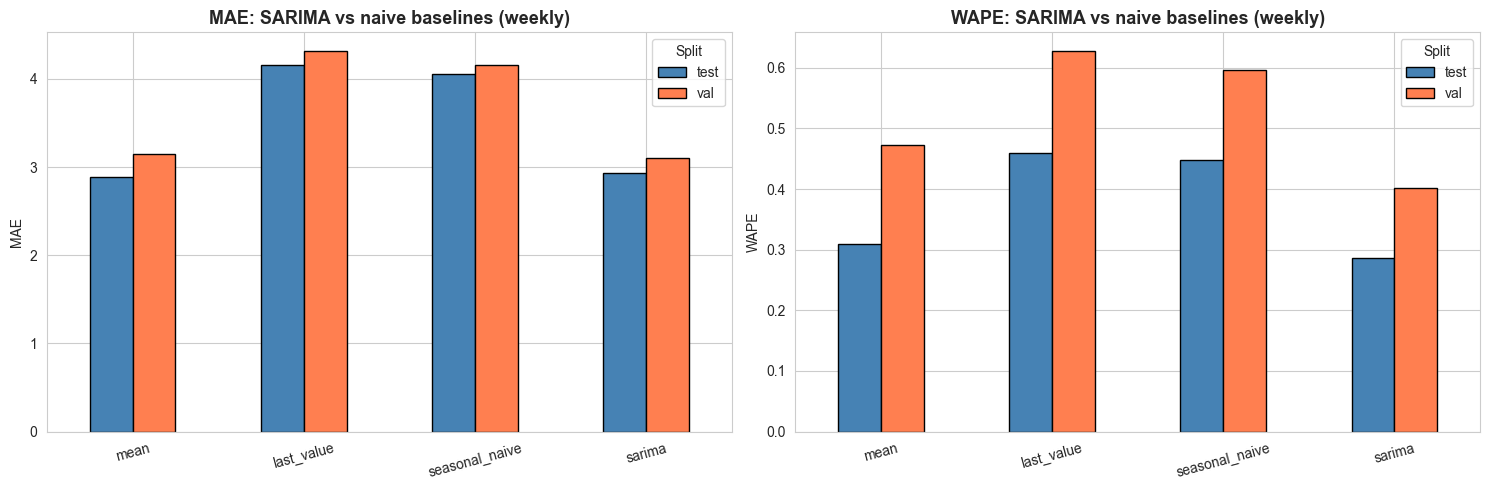

In [6]:
comparison_rows = []

for name, df_n in naive_dfs.items():
    for split in ['val', 'test']:
        sub = df_n[df_n['split'] == split]
        comparison_rows.append({
            'Model': name, 'Split': split,
            'MAE': sub['mae'].mean(), 'RMSE': sub['rmse'].mean(),
            'WAPE': sub['wape'].mean(), 'sMAPE': sub['smape'].mean(),
            'R²': sub['r2'].mean(), 'Bias': sub['bias'].mean(),
        })

for split in ['val', 'test']:
    sp = predictions_df[predictions_df['split'] == split]
    agg = compute_metrics(sp['actual'].values, sp['predicted'].values)
    comparison_rows.append({
        'Model': 'sarima', 'Split': split,
        'MAE': agg['mae'], 'RMSE': agg['rmse'], 'WAPE': agg['wape'],
        'sMAPE': agg['smape'], 'R²': agg['r2'], 'Bias': agg['bias'],
    })

comparison_df = pd.DataFrame(comparison_rows)
print("=" * 80)
print("SARIMA WEEKLY — vs naive baselines")
print("=" * 80)
print(comparison_df.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE', 'WAPE']):
    pivot = comparison_df.pivot(index='Model', columns='Split', values=metric)
    pivot = pivot.reindex(['mean', 'last_value', 'seasonal_naive', 'sarima'])
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric}: SARIMA vs naive baselines (weekly)')
    ax.set_ylabel(metric); ax.set_xlabel('')
    ax.legend(title='Split')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('sarima_weekly_vs_baselines.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-item metrics

In [7]:
per_item_metrics = []

for split in ['val', 'test']:
    split_pred = predictions_df[predictions_df['split'] == split]
    for item in items:
        item_pred = split_pred[split_pred['item_name'] == item]
        if len(item_pred) > 0:
            m = compute_metrics(
                item_pred['actual'].values,
                item_pred['predicted'].values,
                train_data_dict[item]
            )
            m['item_name'] = item
            m['split'] = split
            m['n_predictions'] = len(item_pred)
            per_item_metrics.append(m)

metrics_df = pd.DataFrame(per_item_metrics)
print(f"Per-item metrics: {len(metrics_df)} rows")

Per-item metrics: 244 rows


## 8. Per-section evaluation

SARIMA WEEKLY — Per-section metrics
      section split  n_items    mae   rmse   wape  smape      r2    bias
     American  test       21 3.1860 4.0109 0.2776 0.2934 -0.1522  1.2117
     American   val       21 3.6280 4.3423 0.3920 0.3967 -0.3785 -1.3782
         Cafe  test       17 3.8078 4.9079 0.2819 0.2928 -0.2923  2.2783
         Cafe   val       17 4.0230 4.8393 0.4605 0.4680 -0.6746 -2.1764
Healthy_Vegan  test       12 2.7255 3.4175 0.3455 0.3713 -0.2378  1.2096
Healthy_Vegan   val       12 2.7211 3.2074 0.5587 0.5384 -0.9335 -1.8815
      Italian  test       22 2.7874 3.5967 0.3151 0.3316 -0.1374  0.8483
      Italian   val       22 2.8924 3.4516 0.4924 0.4559 -0.6301 -1.1107
     Japanese  test       16 2.9732 3.6967 0.3317 0.3456 -0.3490  0.2905
     Japanese   val       16 3.2594 3.7938 0.5032 0.4642 -1.2135 -1.9224
      Mexican  test       19 2.5911 3.3187 0.3066 0.3207 -0.0794  0.6924
      Mexican   val       19 2.7409 3.2728 0.3957 0.3985 -0.2725 -0.8262
   Steakhouse  

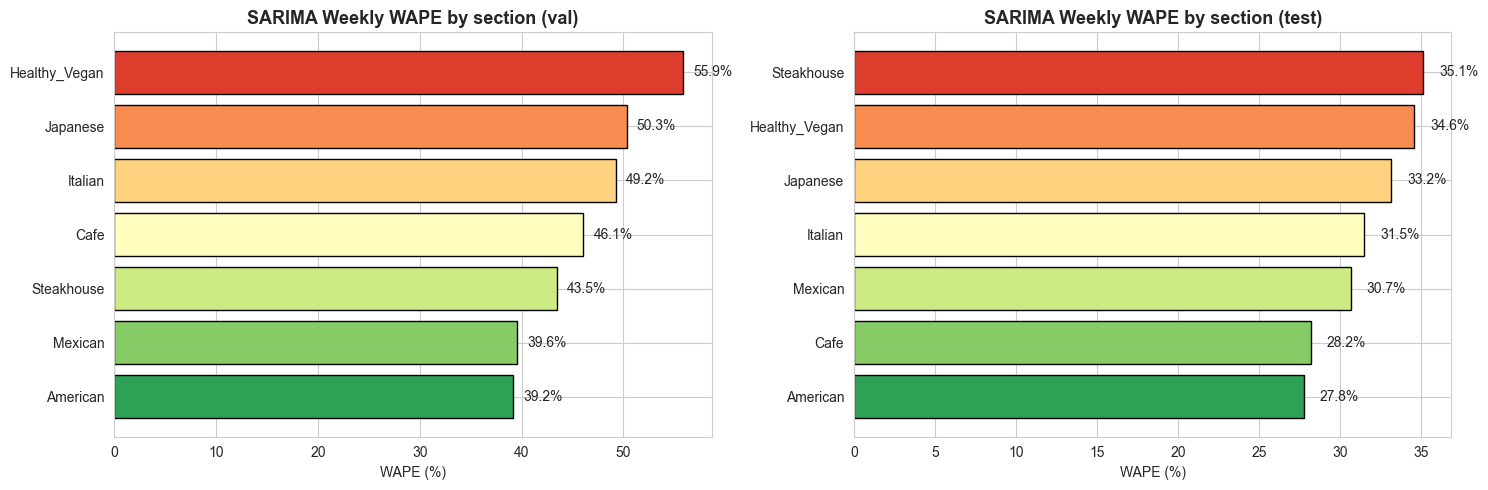

In [8]:
section_map = df[['item_name', 'section', 'category']].drop_duplicates().reset_index(drop=True)
metrics_with_section = metrics_df.merge(section_map, on='item_name')

section_results = metrics_with_section.groupby(['section', 'split']).agg(
    n_items=('item_name', 'nunique'),
    mae=('mae', 'mean'), rmse=('rmse', 'mean'),
    wape=('wape', 'mean'), smape=('smape', 'mean'),
    r2=('r2', 'mean'), bias=('bias', 'mean'),
).reset_index()

print("=" * 70)
print("SARIMA WEEKLY — Per-section metrics")
print("=" * 70)
print(section_results.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, split in zip(axes, ['val', 'test']):
    sec_data = section_results[section_results['split'] == split].sort_values('wape')
    bars = ax.barh(sec_data['section'], sec_data['wape']*100,
                   color=sns.color_palette('RdYlGn_r', len(sec_data)), edgecolor='black')
    ax.set_title(f'SARIMA Weekly WAPE by section ({split})')
    ax.set_xlabel('WAPE (%)')
    for bar, val in zip(bars, sec_data['wape']*100):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('sarima_weekly_per_section.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Per-volume-tier evaluation

SARIMA WEEKLY — Performance by volume tier
     volume_tier split  n_items    mae   wape  smape      r2
     Low (<7/wk)  test       46 2.0524 0.3642 0.3906 -0.0851
     Low (<7/wk)   val       46 2.0479 0.5021 0.5026 -0.3393
Medium (7-35/wk)  test       76 3.4634 0.2809 0.2911 -0.2430
Medium (7-35/wk)   val       76 3.7477 0.4289 0.4118 -0.7683


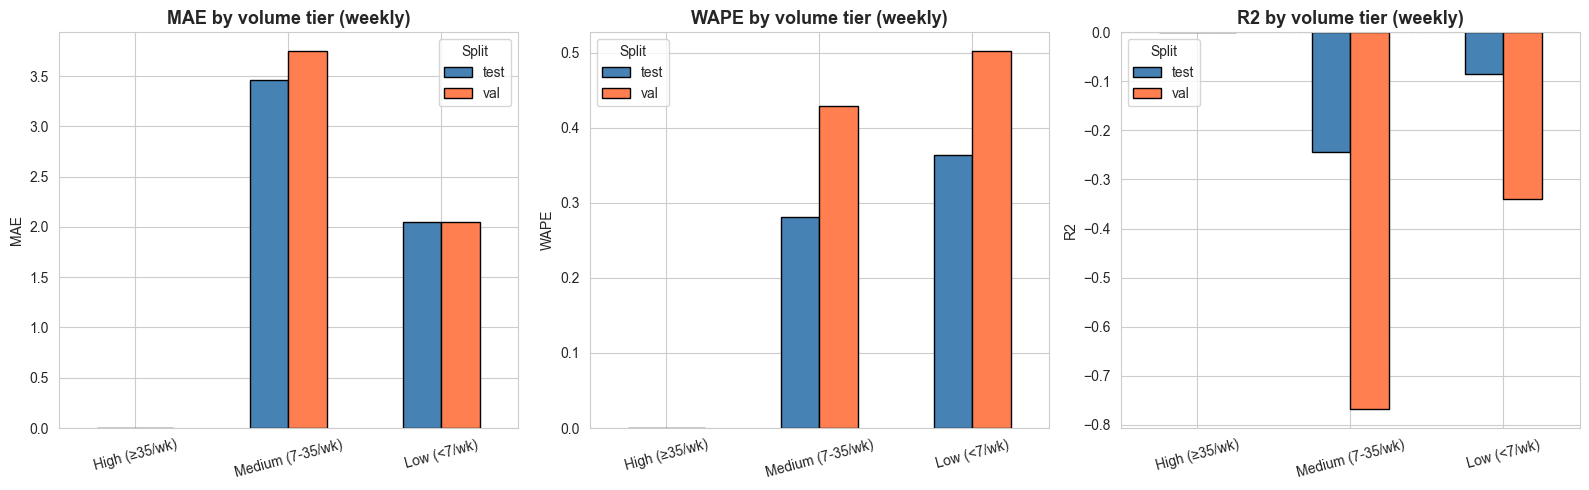

In [9]:
item_volume = df[df['split']=='train'].groupby('item_name')['quantity'].mean().sort_values(ascending=False)

def assign_tier(avg):
    if avg >= 35: return 'High (≥35/wk)'
    elif avg >= 7: return 'Medium (7-35/wk)'
    else: return 'Low (<7/wk)'

item_tiers = item_volume.apply(assign_tier).rename('volume_tier').reset_index()
metrics_with_tier = metrics_df.merge(item_tiers, on='item_name')

tier_order = ['High (≥35/wk)', 'Medium (7-35/wk)', 'Low (<7/wk)']
tier_results = metrics_with_tier.groupby(['volume_tier', 'split']).agg(
    n_items=('item_name', 'nunique'),
    mae=('mae', 'mean'), wape=('wape', 'mean'),
    smape=('smape', 'mean'), r2=('r2', 'mean'),
).reset_index()

print("=" * 70)
print("SARIMA WEEKLY — Performance by volume tier")
print("=" * 70)
print(tier_results.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['mae', 'wape', 'r2']):
    pivot = tier_results.pivot(index='volume_tier', columns='split', values=metric).reindex(tier_order)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric.upper()} by volume tier (weekly)')
    ax.set_ylabel(metric.upper()); ax.set_xlabel('')
    ax.legend(title='Split'); ax.tick_params(axis='x', rotation=15)
    if metric == 'r2':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('sarima_weekly_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Sample predictions

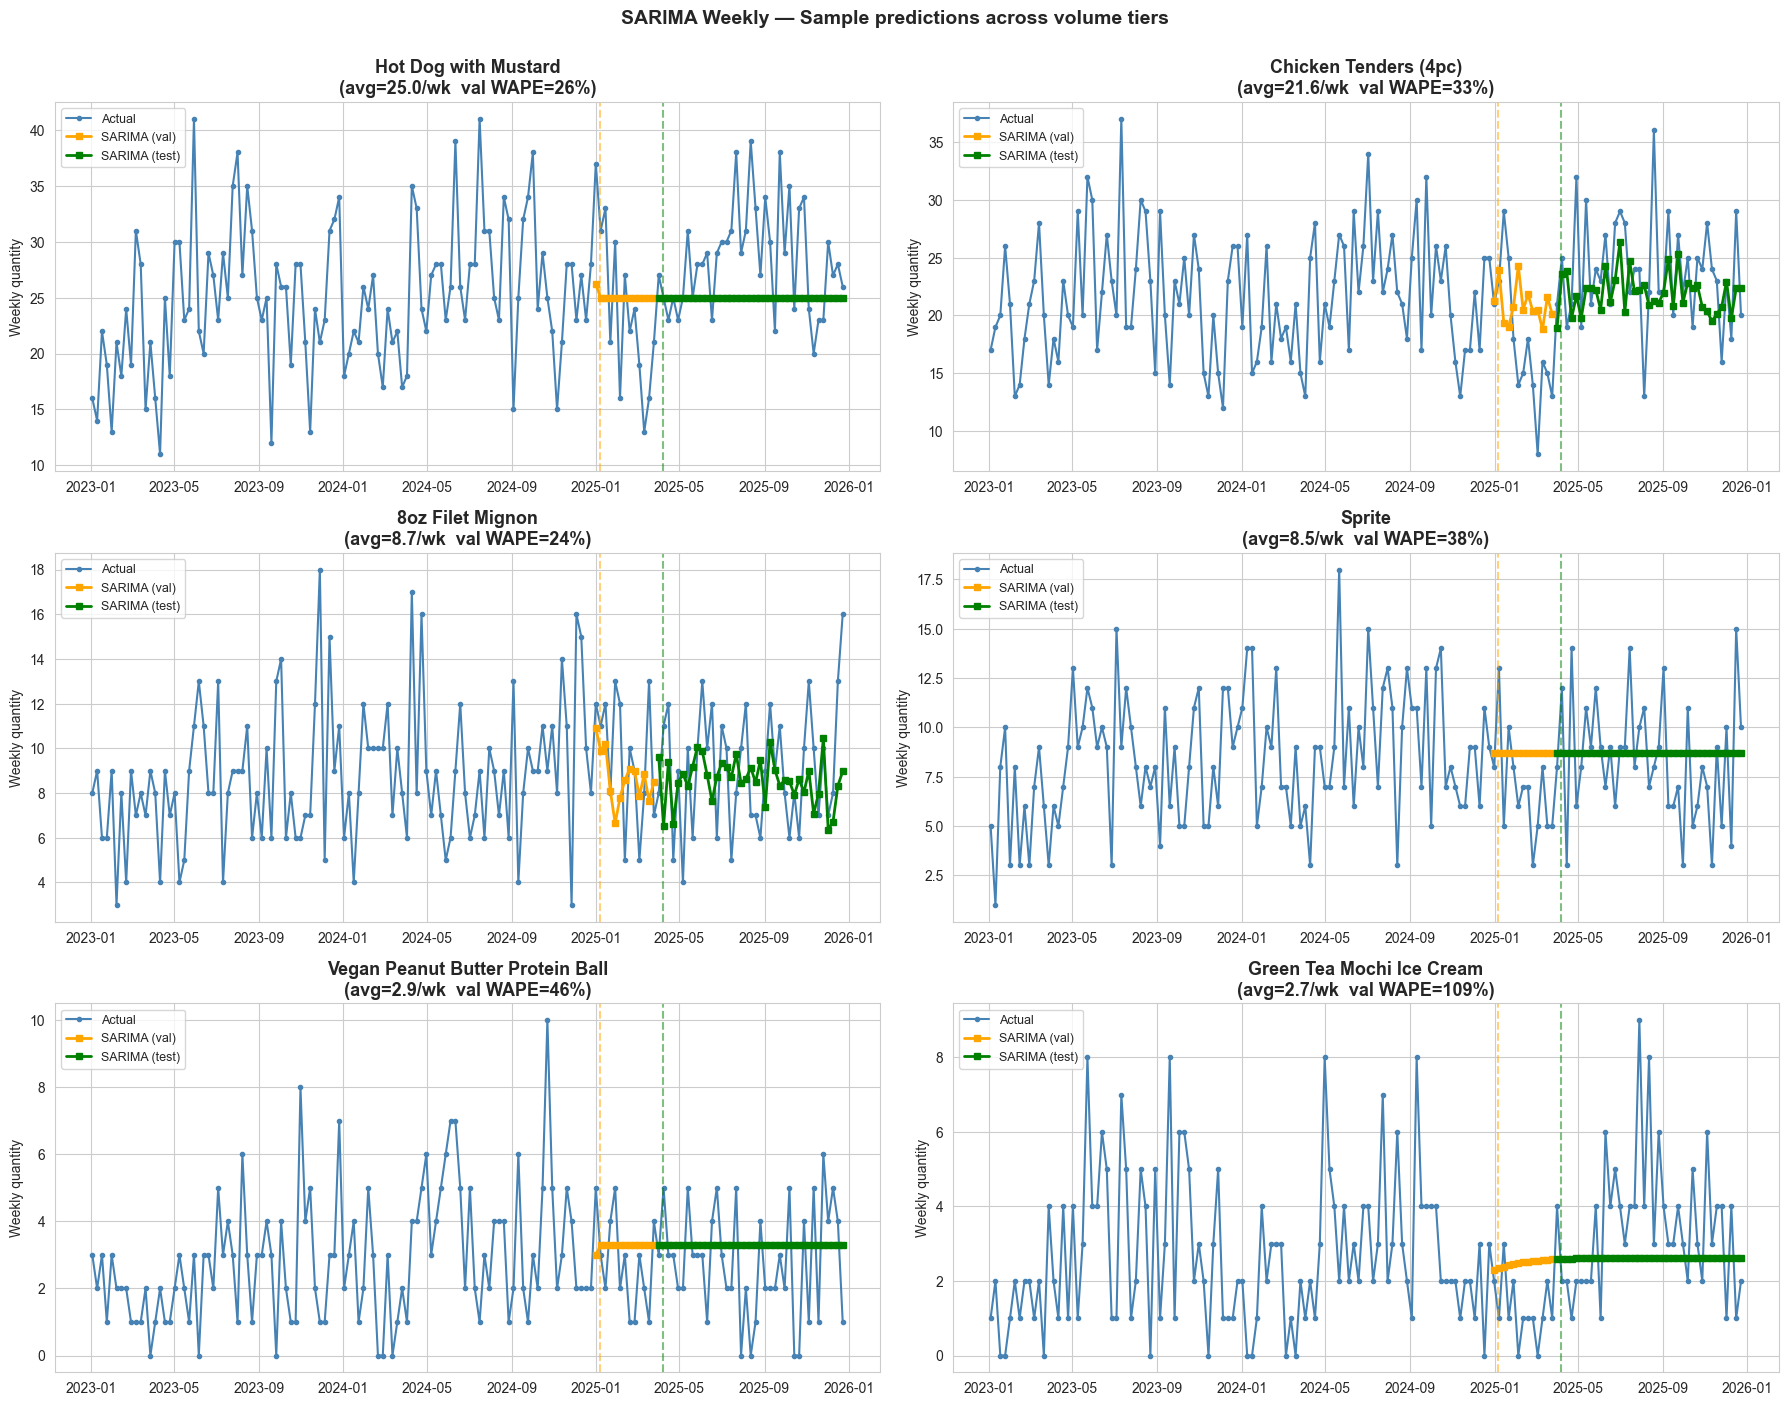

In [10]:
sample_items = []
sample_items += list(item_volume.head(2).index)
mid_idx = len(item_volume) // 2
sample_items += list(item_volume.iloc[mid_idx-1:mid_idx+1].index)
sample_items += list(item_volume.tail(2).index)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, item in zip(axes, sample_items):
    item_full = df[df['item_name'] == item].set_index('week_start')['quantity']
    ax.plot(item_full.index, item_full.values, color='steelblue', linewidth=1.5,
            marker='o', markersize=3, label='Actual')

    item_pred = predictions_df[predictions_df['item_name'] == item].copy()
    item_pred['ds'] = pd.to_datetime(item_pred['ds'])

    for split, color in [('val', 'orange'), ('test', 'green')]:
        sp = item_pred[item_pred['split'] == split].sort_values('ds')
        ax.plot(sp['ds'], sp['predicted'], color=color, linewidth=2,
                marker='s', markersize=4, label=f'SARIMA ({split})')

    ax.axvline(pd.Timestamp('2025-01-06'), color='orange', linestyle='--', alpha=0.5)
    ax.axvline(pd.Timestamp('2025-04-07'), color='green', linestyle='--', alpha=0.5)

    avg = item_volume[item]
    val_metrics = metrics_df[(metrics_df['item_name']==item) & (metrics_df['split']=='val')]
    if len(val_metrics) > 0:
        val_wape = val_metrics['wape'].values[0]
        ax.set_title(f'{item}\n(avg={avg:.1f}/wk  val WAPE={val_wape*100:.0f}%)')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_ylabel('Weekly quantity')

plt.suptitle('SARIMA Weekly — Sample predictions across volume tiers',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('sarima_weekly_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Residual diagnostics

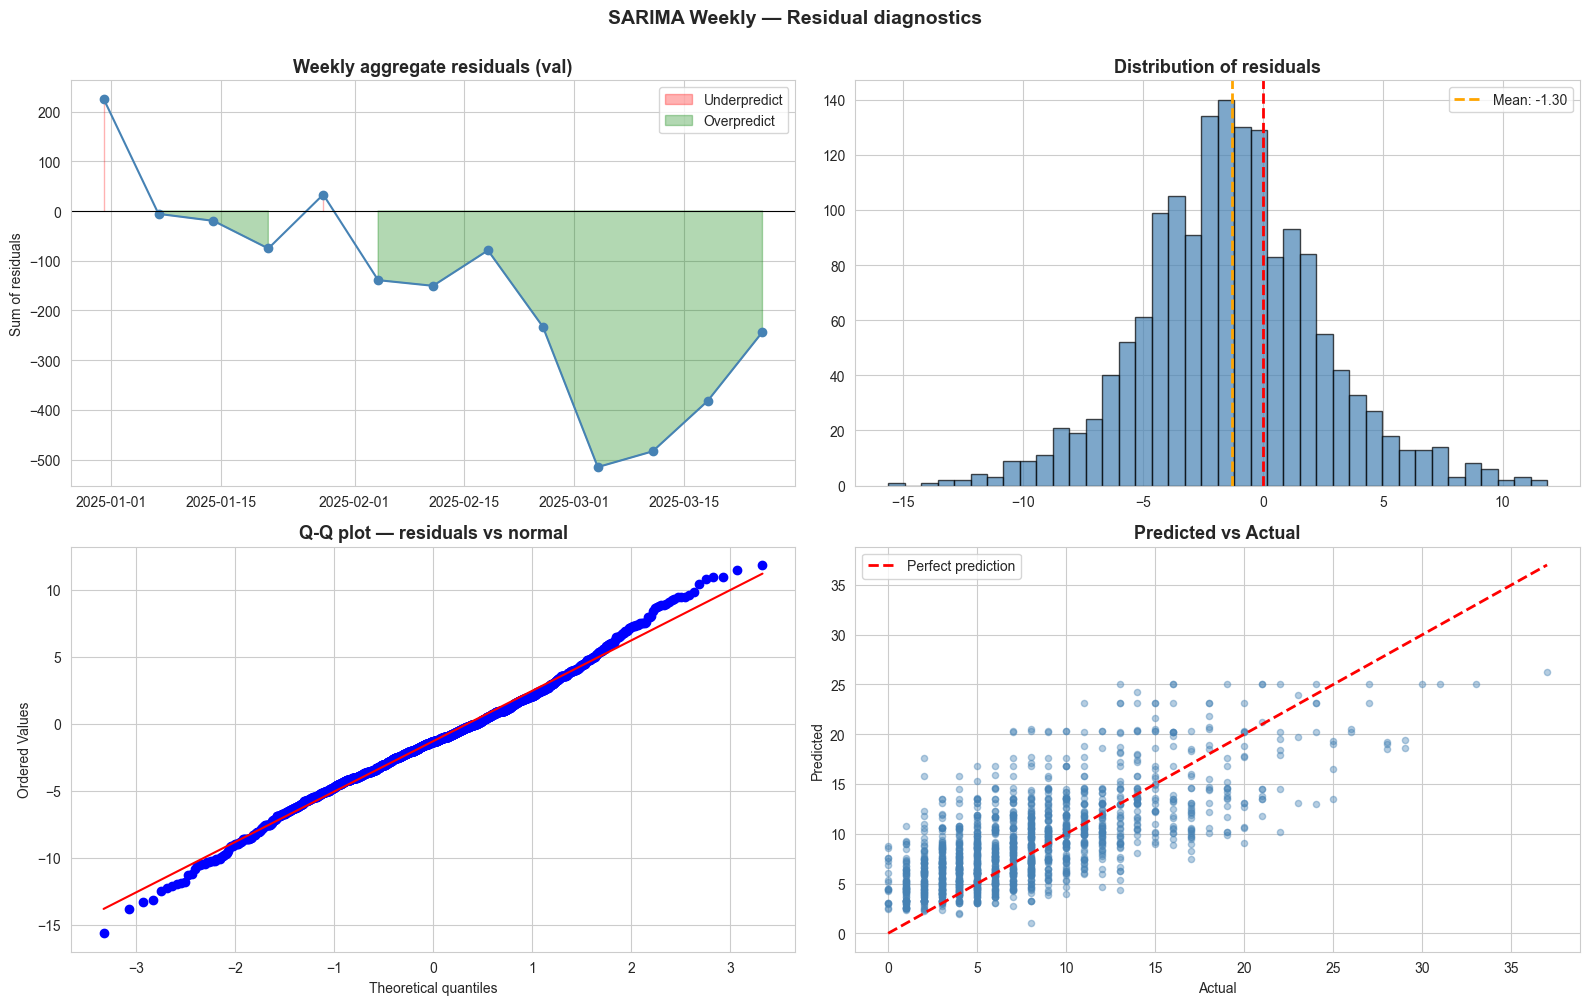

In [11]:
val_pred = predictions_df[predictions_df['split'] == 'val'].copy()
val_pred['residual'] = val_pred['actual'] - val_pred['predicted']
val_pred['ds'] = pd.to_datetime(val_pred['ds'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

weekly_res = val_pred.groupby('ds')['residual'].sum().reset_index()
ax = axes[0, 0]
ax.plot(weekly_res['ds'], weekly_res['residual'], color='steelblue', linewidth=1.5, marker='o')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(weekly_res['ds'], 0, weekly_res['residual'],
                where=(weekly_res['residual'] > 0), alpha=0.3, color='red', label='Underpredict')
ax.fill_between(weekly_res['ds'], 0, weekly_res['residual'],
                where=(weekly_res['residual'] <= 0), alpha=0.3, color='green', label='Overpredict')
ax.set_title('Weekly aggregate residuals (val)')
ax.set_ylabel('Sum of residuals'); ax.legend()

ax = axes[0, 1]
ax.hist(val_pred['residual'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.axvline(val_pred['residual'].mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Mean: {val_pred["residual"].mean():.2f}')
ax.set_title('Distribution of residuals'); ax.legend()

ax = axes[1, 0]
stats.probplot(val_pred['residual'], dist='norm', plot=ax)
ax.set_title('Q-Q plot — residuals vs normal')

ax = axes[1, 1]
ax.scatter(val_pred['actual'], val_pred['predicted'], alpha=0.4, s=20, color='steelblue')
max_val = max(val_pred['actual'].max(), val_pred['predicted'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title('Predicted vs Actual'); ax.legend()

plt.suptitle('SARIMA Weekly — Residual diagnostics', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('sarima_weekly_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Per-item WAPE distribution

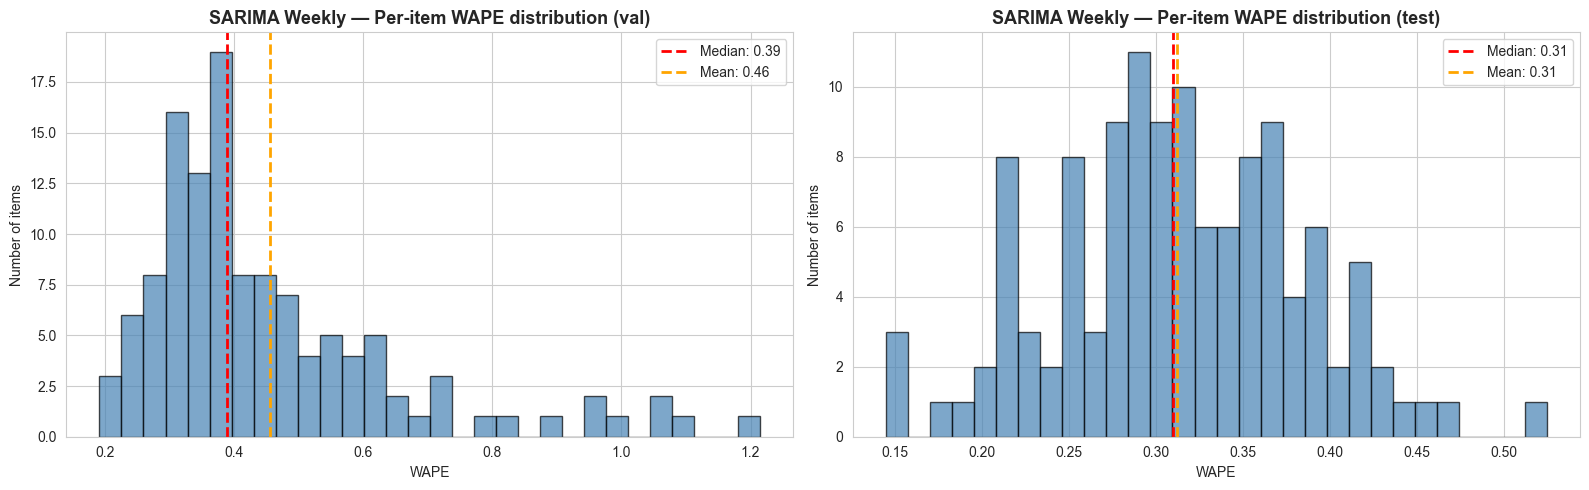

BEST 10 items (lowest WAPE on val):
              item_name    mae   wape      r2
        Chicken Burrito 2.4643 0.1918 -0.0018
            Dragon Roll 2.0520 0.1991 -0.7885
     Philly Cheesesteak 3.3030 0.2248 -0.3760
Crispy Chicken Sandwich 4.3918 0.2284  0.0823
       8oz Filet Mignon 2.2840 0.2375 -0.2047
     Fettuccine Alfredo 3.1468 0.2406 -0.3478
     Chicken Enchiladas 3.1836 0.2539  0.0371
       Beef Tacos (3pc) 3.6153 0.2568  0.0053
   Hot Dog with Mustard 6.1352 0.2573  0.0169
       Margherita Pizza 2.5197 0.2621 -0.6698

WORST 10 items (highest WAPE on val):
                item_name    mae   wape      r2
                 Prosecco 4.4865 1.2151 -4.1971
Green Tea Mochi Ice Cream 1.3380 1.0872 -2.5200
        Grilled Asparagus 3.4726 1.0499 -3.1403
             Lemon Gelato 1.7684 1.0450 -0.8517
            Caprese Salad 2.3498 0.9854 -0.9021
        Vanilla Milkshake 2.5397 0.9710 -0.7134
            Sapporo Draft 2.6375 0.9524 -1.0788
       Tuna Sashimi (5pc) 6.4140 0.

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, split in zip(axes, ['val', 'test']):
    split_metrics = metrics_df[metrics_df['split'] == split]
    wape_clipped = split_metrics['wape'].clip(upper=2)

    ax.hist(wape_clipped, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(wape_clipped.median(), color='red', linestyle='--', linewidth=2,
               label=f'Median: {wape_clipped.median():.2f}')
    ax.axvline(wape_clipped.mean(), color='orange', linestyle='--', linewidth=2,
               label=f'Mean: {wape_clipped.mean():.2f}')
    ax.set_title(f'SARIMA Weekly — Per-item WAPE distribution ({split})')
    ax.set_xlabel('WAPE'); ax.set_ylabel('Number of items'); ax.legend()
plt.tight_layout()
plt.savefig('sarima_weekly_wape_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 70)
print("BEST 10 items (lowest WAPE on val):")
print("=" * 70)
print(metrics_df[metrics_df['split']=='val'].nsmallest(10, 'wape')[['item_name', 'mae', 'wape', 'r2']].to_string(index=False, float_format='%.4f'))

print("\n" + "=" * 70)
print("WORST 10 items (highest WAPE on val):")
print("=" * 70)
print(metrics_df[metrics_df['split']=='val'].nlargest(10, 'wape')[['item_name', 'mae', 'wape', 'r2']].to_string(index=False, float_format='%.4f'))

## 13. Save fitted models

In [13]:
for item, model in fitted_models.items():
    safe_name = item.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
    model_path = os.path.join(MODELS_DIR, f'{safe_name}.pkl')
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)

manifest = {
    'model_type': 'sarima_per_item_weekly',
    'n_items': len(fitted_models),
    'granularity': 'weekly',
    'seasonal_period_m': 4,
    'forecast_horizon_weeks': 18,
    'items': sorted(fitted_models.keys()),
    'failed_items': [item for item, _ in failed_items],
}
with open(os.path.join(MODELS_DIR, 'manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=2, default=str)

print(f"✓ Saved {len(fitted_models)} per-item SARIMA models")
print(f"✓ Manifest: {MODELS_DIR}/manifest.json")

✓ Saved 121 per-item SARIMA models
✓ Manifest: ../../models/sarima/manifest.json


## 14. Save predictions, metrics, summary

In [14]:
output_cols = ['ds', 'item_name', 'actual', 'predicted', 'split']
predictions_df[output_cols].to_csv(os.path.join(DATASETS_DIR, 'sarima_predictions_weekly.csv'), index=False)
metrics_df.to_csv(os.path.join(DATASETS_DIR, 'sarima_metrics_weekly.csv'), index=False)

summary = {
    'model': 'sarima_weekly',
    'granularity': 'weekly',
    'seasonal_period_m': 4,
    'n_items': len(items),
    'training_time_seconds': total_time,
    'overall_metrics': {},
    'per_section_metrics': {},
    'per_volume_tier_metrics': {},
    'baseline_comparison': {},
}

for split in ['val', 'test']:
    sp = predictions_df[predictions_df['split'] == split]
    summary['overall_metrics'][split] = {
        k: float(v) for k, v in compute_metrics(sp['actual'].values, sp['predicted'].values).items()
    }

for split in ['val', 'test']:
    summary['per_section_metrics'][split] = {}
    for sec in section_results['section'].unique():
        row = section_results[(section_results['section']==sec) & (section_results['split']==split)]
        if len(row) > 0:
            summary['per_section_metrics'][split][sec] = {
                'mae': float(row['mae'].values[0]),
                'wape': float(row['wape'].values[0]),
                'r2': float(row['r2'].values[0]),
            }

for split in ['val', 'test']:
    summary['per_volume_tier_metrics'][split] = {}
    for tier in tier_order:
        row = tier_results[(tier_results['volume_tier']==tier) & (tier_results['split']==split)]
        if len(row) > 0:
            summary['per_volume_tier_metrics'][split][tier] = {
                'mae': float(row['mae'].values[0]),
                'wape': float(row['wape'].values[0]),
                'r2': float(row['r2'].values[0]),
            }

for _, row in comparison_df.iterrows():
    key = f"{row['Model']}_{row['Split']}"
    summary['baseline_comparison'][key] = {
        'mae': float(row['MAE']), 'wape': float(row['WAPE']), 'r2': float(row['R²']),
    }

with open(os.path.join(DATASETS_DIR, 'sarima_summary_weekly.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("=" * 60)
print("SARIMA WEEKLY — COMPLETE")
print("=" * 60)
print(f"\nVal WAPE: {summary['overall_metrics']['val']['wape']:.4f}")
print(f"Val R²:   {summary['overall_metrics']['val']['r2']:+.4f}")
print(f"Test WAPE: {summary['overall_metrics']['test']['wape']:.4f}")
print(f"Test R²:   {summary['overall_metrics']['test']['r2']:+.4f}")
print(f"\nDaily reference: SARIMA daily val WAPE 0.8109 R² +0.1235")
print(f"\nNext: 04c_statistical_comparison_weekly.ipynb")

SARIMA WEEKLY — COMPLETE

Val WAPE: 0.4019
Val R²:   +0.4211
Test WAPE: 0.2867
Test R²:   +0.5821

Daily reference: SARIMA daily val WAPE 0.8109 R² +0.1235

Next: 04c_statistical_comparison_weekly.ipynb
